<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE-NO-SUPERVISADO/blob/main/Taller3_MARIO_GUERRERO_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller de clustering**

**Objetivo del taller**

Para la base de datos suministrada realizar un modelo de clustering, probando los 3 métodos, justificando su decisión de cual es el mejor metodo y el número de clusters seleccionado.

Recuerde que es muy importante el análisis previo de los datos, para la selección y tratamiento de las variables.

Una vez definido el clustering, con su respectiva justificación, se debe caracterizar el clustering realizado.

**Descripcion de variables**

CUST_ID: Identificador único del cliente.

BALANCE: Saldo promedio mensual en la cuenta de la tarjeta.

BALANCE_FREQUENCY:Frecuencia con la que el saldo se actualiza (valor entre 0 y 1).

PURCHASES: Monto total de compras realizadas con la tarjeta.

ONEOFF_PURCHASES: Compras realizadas en una sola transacción (no recurrentes).

INSTALLMENTS_PURCHASES: Compras realizadas a cuotas.

PURCHASES_FREQUENCY: Frecuencia de compras (0–1).

ONEOFF_PURCHASES_FREQUENCY: Frecuencia de compras únicas.

PURCHASES_INSTALLMENTS_FREQUENCY: Frecuencia de compras a cuotas.

CASH_ADVANCE: Total de avances en efectivo.

CASH_ADVANCE_FREQUENCY: Frecuencia de avances en efectivo.

CASH_ADVANCE_TRX: Número de transacciones de avances en efectivo.

PURCHASES_TRX: Número de transacciones de compra.

CREDIT_LIMIT: Límite de crédito asignado al cliente.

PAYMENTS: Total de pagos realizados por el cliente.

MINIMUM_PAYMENTS: Pago mínimo requerido.

PRC_FULL_PAYMENT: Porcentaje de meses en los que el cliente pagó el saldo completo (0–1).

TENURE: Número de meses que el cliente ha estado con la tarjeta.


1. Montamos la libreria

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans


Mounted at /content/drive


1.1 montamos archivo

In [ ]:
datos =pd.read_csv("/content/drive/MyDrive/APREN. NO SUPERVISADO/CC GENERAL.csv" )
datos.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


1.2 eliminamos vacios

In [ ]:
datos.isna().sum()
datos =datos.dropna()
datos.shape

(8636, 18)

2. analisis de las variables

2.1 Eliminamos la variable CUST_ID

In [ ]:
datos = datos.drop('CUST_ID', axis=1)
datos.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


2.2 Hacemos matriz de correlacion

In [ ]:
corr_matrix = datos.corr()
corr_matrix

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.310140,0.176083,0.159985,0.122109,0.495586,-0.088459,0.063832,-0.069582,0.445307,0.382388,0.147887,0.535518,0.322830,0.398669,-0.333594,0.066987
BALANCE_FREQUENCY,0.310140,1.000000,0.122635,0.095254,0.114739,0.089036,0.228158,0.187467,0.184159,0.181132,0.133265,0.183095,0.087682,0.039169,0.132519,-0.156961,0.104714
PURCHASES,0.176083,0.122635,1.000000,0.916780,0.679259,-0.053760,0.393000,0.497384,0.316025,-0.124863,-0.070277,0.688732,0.358425,0.606782,0.093842,0.176447,0.084545
ONEOFF_PURCHASES,0.159985,0.095254,0.916780,1.000000,0.329650,-0.033244,0.265460,0.524514,0.128380,-0.086413,-0.048705,0.545313,0.320613,0.570850,0.048741,0.129890,0.063400
INSTALLMENTS_PURCHASES,0.122109,0.114739,0.679259,0.329650,1.000000,-0.066099,0.441193,0.211829,0.511130,-0.136455,-0.076716,0.626083,0.258057,0.385391,0.132156,0.178440,0.083346
CASH_ADVANCE,0.495586,0.089036,-0.053760,-0.033244,-0.066099,1.000000,-0.218566,-0.090111,-0.178873,0.629030,0.656911,-0.078449,0.304161,0.459342,0.140094,-0.158566,-0.073090
PURCHASES_FREQUENCY,-0.088459,0.228158,0.393000,0.265460,0.441193,-0.218566,1.000000,0.502123,0.862338,-0.316771,-0.208749,0.567168,0.121372,0.100715,0.002979,0.305393,0.052161
ONEOFF_PURCHASES_FREQUENCY,0.063832,0.187467,0.497384,0.524514,0.211829,-0.090111,0.502123,1.000000,0.143911,-0.118225,-0.073384,0.544364,0.295432,0.244346,-0.030357,0.154073,0.080437
PURCHASES_INSTALLMENTS_FREQUENCY,-0.069582,0.184159,0.316025,0.128380,0.511130,-0.178873,0.862338,0.143911,1.000000,-0.268924,-0.172811,0.529192,0.063421,0.083424,0.030036,0.249547,0.065779
CASH_ADVANCE_FREQUENCY,0.445307,0.181132,-0.124863,-0.086413,-0.136455,0.629030,-0.316771,-0.118225,-0.268924,1.000000,0.799593,-0.136913,0.132841,0.182340,0.098844,-0.260001,-0.140038


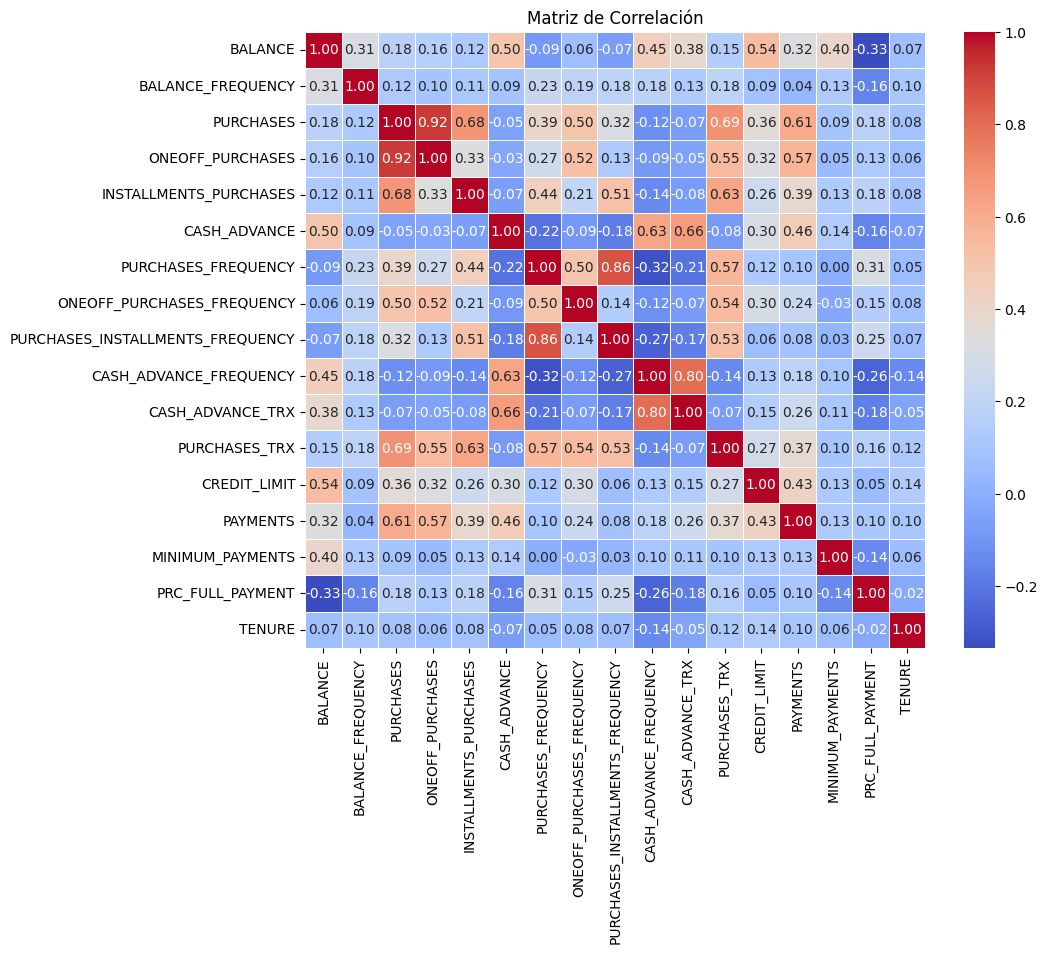

In [ ]:
plt.figure(figsize=(10,8))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

**ANALISIS DE MATRIZ DE COORREALCION**

La matriz de correlación muestra que existen grupos de variables fuertemente relacionadas entre sí, lo que indica posible redundancia de información. Por ejemplo, PURCHASES y ONEOFF_PURCHASES presentan una correlación muy alta (≈0.92), al igual que PURCHASES_FREQUENCY y PURCHASES_INSTALLMENTS_FREQUENCY (≈0.86) y CASH_ADVANCE con CASH_ADVANCE_TRX (≈0.80), lo que sugiere que no es conveniente incluir ambas variables de cada grupo en un modelo de clustering porque estaríamos duplicando información. También se observan correlaciones moderadas entre compras, pagos y límite de crédito, lo cual es lógico ya que el consumo influye en los pagos y en la capacidad financiera del cliente. Por otro lado, variables como TENURE, PRC_FULL_PAYMENT y algunas frecuencias muestran correlaciones bajas con la mayoría de variables, lo que es positivo porque aportan información diferente y ayudan a diferenciar mejor los perfiles. En general, la matriz evidencia que para construir un buen modelo de clustering se debe elegir una variable representativa por cada bloque altamente correlacionado y combinarla con variables que midan dimensiones distintas del comportamiento financiero del cliente.


# **3. K-MEANS**

Para el modelo K-Means seleccionaré las variables BALANCE, PURCHASES, PURCHASES_FREQUENCY, CASH_ADVANCE, CREDIT_LIMIT, PRC_FULL_PAYMENT y TENURE, ya que este algoritmo funciona mejor cuando se representan distintas dimensiones del comportamiento del cliente sin redundancia excesiva. Estas variables permiten capturar el nivel de deuda, el nivel de consumo, la frecuencia de uso de la tarjeta, el uso de avances en efectivo, la capacidad financiera, el comportamiento de pago y la antigüedad del cliente. De esta manera se construye un perfil financiero más completo que no solo refleja cuánto consume el cliente, sino también con qué frecuencia utiliza la tarjeta y qué tan responsable es con sus pagos, lo que facilita una segmentación más clara y representativa de los distintos tipos de clientes.

In [ ]:
datos_kmeans = datos[[ 'BALANCE',
                      'PURCHASES',
                      'PURCHASES_FREQUENCY',
                      'CASH_ADVANCE',
                      'CREDIT_LIMIT',
                      'PRC_FULL_PAYMENT',
                      'TENURE']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(datos_kmeans)

In [ ]:
datos_kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=5, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [ ]:
datos_kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=5, n_init=10, random_state=42)

In [ ]:
datos_kmeans.inertia_

29113.21240854217

In [ ]:
datos_kmeans.cluster_centers_

array([[ 2.14246706,  0.31766656, -0.21516925,  1.70519455,  1.52496964,
        -0.45115405,  0.17104923],
       [-0.66853054,  0.46058769,  0.72873573, -0.4262717 ,  0.23349375,
         2.18404262,  0.23570893],
       [-0.3077381 , -0.2682778 , -0.13141194,  0.10036093, -0.528658  ,
         0.00515464, -3.16836827],
       [-0.17915554, -0.37356975, -0.89966687, -0.09814025, -0.3539309 ,
        -0.40890673,  0.25936174],
       [-0.1556393 ,  0.21495213,  0.9159981 , -0.31625516, -0.0731373 ,
        -0.32954608,  0.29877316]])

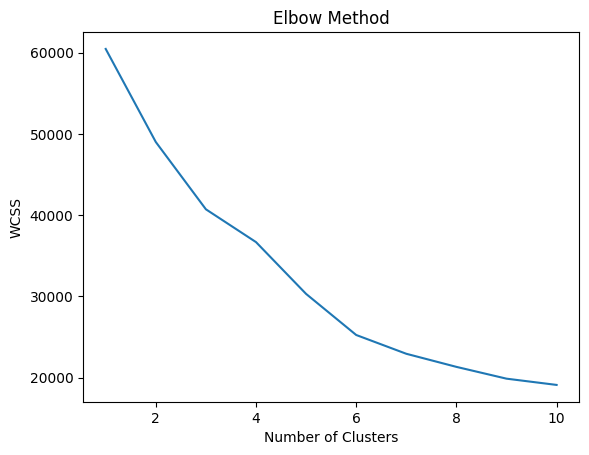

In [ ]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    datos_kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    datos_kmeans.fit(scaled_features)
    wcss.append(datos_kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
datos_kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=3, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [ ]:
datos_kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=3, n_init=10, random_state=42)

In [ ]:
standardized_centroids = datos_kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[1.10151646e+03, 6.16594445e+02, 4.24203581e-01, 5.88510484e+02,
        3.22434046e+03, 4.07677403e-02, 1.15103341e+01],
       [5.32131580e+03, 1.84554090e+03, 4.60223178e-01, 3.76060339e+03,
        9.53013782e+03, 2.48556535e-02, 1.16601942e+01],
       [2.06258738e+02, 1.88096601e+03, 8.07707027e-01, 8.94433350e+01,
        5.07807034e+03, 7.41627689e-01, 1.15150905e+01]])

In [ ]:
labels = datos_kmeans.predict(scaled_features)
datos['cluster'] = labels
datos

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,0
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,2
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,0
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0


In [ ]:
datos['cluster'].value_counts()

,count
cluster,
0,5804
2,1489
1,1343


In [ ]:
silhouette_avg_kmeans = silhouette_score(scaled_features, labels)
print(f"Silhouette Score para K-Means: {silhouette_avg_kmeans}")

Silhouette Score para K-Means: 0.31489399364888637


# **ANALISIS K-MEANS**

El modelo K-Means generó tres clusters con una distribución relativamente equilibrada entre los grupos, donde el cluster 0 concentra la mayor cantidad de clientes (5804), seguido por los clusters 2 (1489) y 1 (1343). Esta distribución indica que el modelo logró identificar un grupo predominante de clientes con características similares y dos segmentos adicionales con comportamientos financieros diferenciados. Sin embargo, el Silhouette Score de aproximadamente 0.315 sugiere que la separación entre los clusters es moderada, lo que significa que aunque existen diferencias entre los grupos, estas no son extremadamente marcadas. En términos de interpretación, el modelo logra segmentar a los clientes, pero los límites entre algunos grupos podrían ser relativamente cercanos, lo que reduce un poco la claridad de la segmentación.

# **4. DBSCAN**

La razón es que ambas variables representan las dos dimensiones más importantes del comportamiento financiero del cliente: el nivel de deuda acumulada (BALANCE) y el nivel de consumo o uso de la tarjeta (PURCHASES). Además, aunque tienen cierta correlación, no es lo suficientemente alta como para ser redundantes, por lo que aportan información complementaria. Con solo estas dos variables, DBSCAN puede identificar de forma más clara clientes con alto consumo y alta deuda, clientes con bajo uso, y posibles outliers financieros, sin verse afectado por una dimensionalidad excesiva que pueda dificultar la detección de densidades.

In [ ]:
datos_dbscan= datos.loc[:, ['BALANCE','PURCHASES']] # Se seleccionan solo las dos columnas con las que se va a trabajar
scaler = StandardScaler()
scaled_features = scaler.fit_transform(datos_dbscan)

In [ ]:
db = DBSCAN(eps=1.0, min_samples=5).fit(scaled_features)

In [ ]:
datos_dbscan.loc[:, 'dbscan_labels'] = db.labels_

In [ ]:
datos_dbscan.head()

,BALANCE,PURCHASES,dbscan_labels
0,40.900749,95.40,0
1,3202.467416,0.00,0
2,2495.148862,773.17,0
4,817.714335,16.00,0
5,1809.828751,1333.28,0


In [ ]:
datos_dbscan['dbscan_labels'].value_counts()

,count
dbscan_labels,
0,8602
-1,29
1,5


In [ ]:
dbscan_labels = db.labels_
silhouette_avg = silhouette_score(scaled_features, dbscan_labels)
print("DBSCAN Silhouette Score:", silhouette_avg)

DBSCAN Silhouette Score: 0.8748518199997979


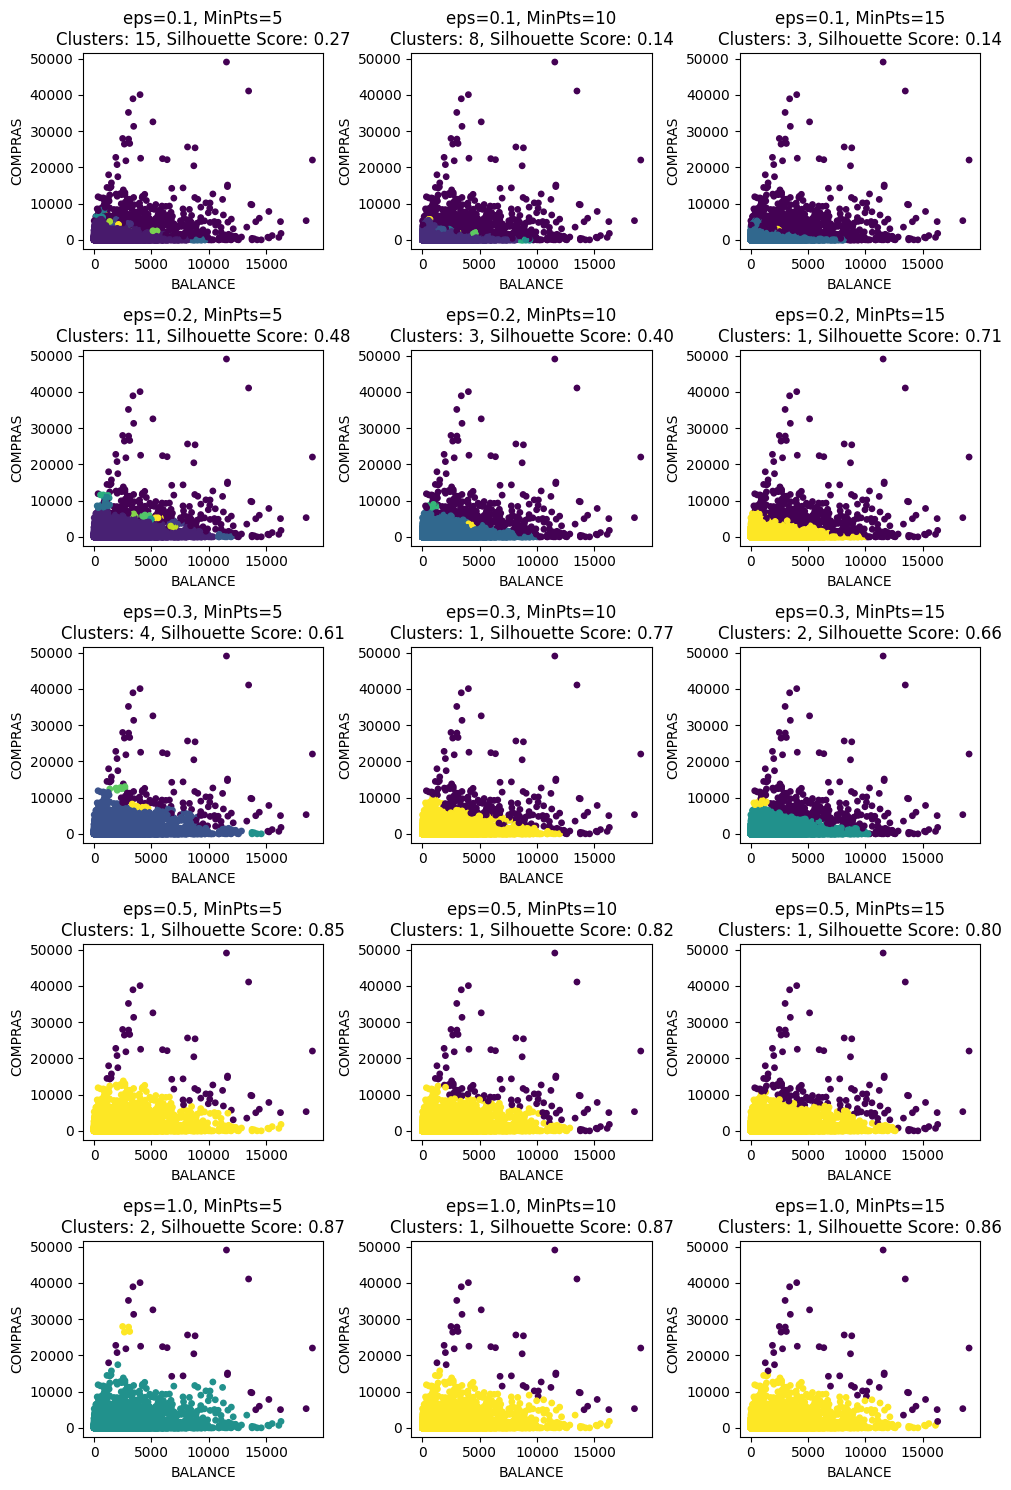

In [ ]:
eps_values = [0.1, 0.2, 0.3, 0.5, 1.0]
minPts_values = [5, 10, 15]

results = []
fig, axs = plt.subplots(len(eps_values), len(minPts_values), figsize=(10, 15))

for i, minPts in enumerate(minPts_values):
    for j, eps in enumerate(eps_values):

        dbscan_model = DBSCAN(eps=eps, min_samples=minPts)
        dbscan_labels = dbscan_model.fit_predict(scaled_features)


        silhouette_avg = silhouette_score(scaled_features, dbscan_labels)

        unique_labels = set(dbscan_model.labels_)
        unique_labels.discard(-1)
        num_clusters = len(unique_labels)


        axs[j, i].scatter(datos_dbscan['BALANCE'], datos_dbscan['PURCHASES'], c=dbscan_labels, s=15)
        axs[j, i].set_title(f'eps={eps}, MinPts={minPts}\nClusters: {num_clusters}, Silhouette Score: {silhouette_avg:.2f}')
        axs[j, i].set_ylabel('COMPRAS')
        axs[j, i].set_xlabel('BALANCE')


        results.append({
            'Epsilon (eps)': eps,
            'MinPts': minPts,
            'Silhouette Score': silhouette_avg,
            'Numero de clusters': num_clusters
        })

plt.tight_layout()
plt.show()

In [ ]:
results_df= pd.DataFrame(results)
results_df

,Epsilon (eps),MinPts,Silhouette Score,Numero de clusters
0,0.1,5,0.269679,15
1,0.2,5,0.479610,11
2,0.3,5,0.610229,4
3,0.5,5,0.850964,1
4,1.0,5,0.874852,2
5,0.1,10,0.136815,8
6,0.2,10,0.395189,3
7,0.3,10,0.769560,1
8,0.5,10,0.819869,1
9,1.0,10,0.867083,1


Text(0.5, 1.0, 'Desempeño de los modelos según el coeficiente de la silueta')

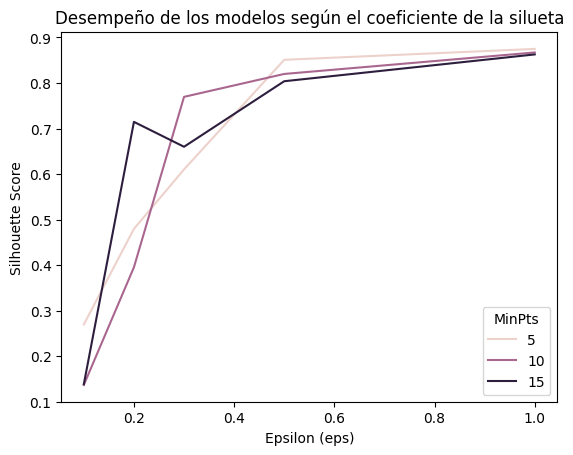

In [ ]:
sns.lineplot(x=results_df['Epsilon (eps)'], y=results_df['Silhouette Score'], hue=results_df['MinPts'])
plt.title('Desempeño de los modelos según el coeficiente de la silueta')

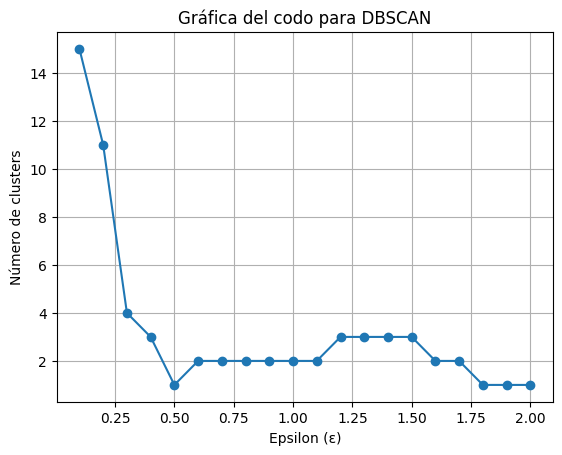

In [ ]:
epsilon_values = np.linspace(0.1, 2.0, 20)


num_clusters = []


for epsilon in epsilon_values:
    dbscan_model = DBSCAN(eps=epsilon)
    dbscan_labels = dbscan_model.fit_predict(scaled_features)


    num_clusters.append(len(np.unique(dbscan_labels)) - 1)


plt.plot(epsilon_values, num_clusters, marker='o')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Número de clusters')
plt.title('Gráfica del codo para DBSCAN')
plt.grid(True)
plt.show()

In [ ]:
db = DBSCAN(eps=0.7, min_samples=5).fit(scaled_features)
datos_dbscan.loc[:, 'dbscan_labels'] = db.labels_

In [ ]:
datos_dbscan.groupby('dbscan_labels')[['BALANCE','PURCHASES']].corr()

BALANCE  PURCHASES
dbscan_labels                               
-1            BALANCE    1.000000  -0.452677
              PURCHASES -0.452677   1.000000
 0            BALANCE    1.000000   0.112298
              PURCHASES  0.112298   1.000000
 1            BALANCE    1.000000  -0.295672
              PURCHASES -0.295672   1.000000

Text(0.5, 1.0, 'Diagrama de dispersión para DBSCAN')

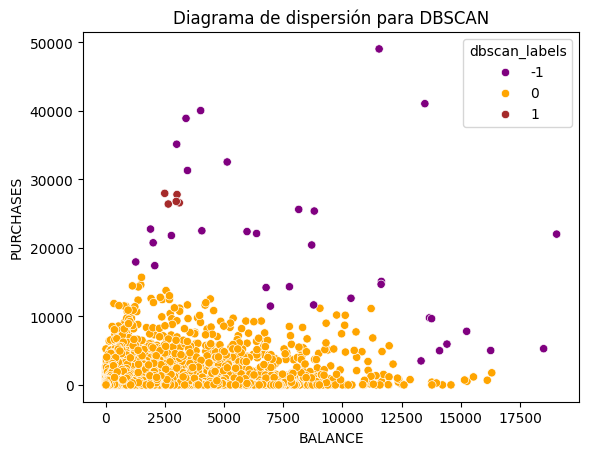

In [ ]:
custom_palette = {-1:'purple', 0:'orange', 1:'brown'}
sns.scatterplot(data=datos_dbscan,x='BALANCE',y='PURCHASES', hue='dbscan_labels', palette=custom_palette)
plt.title('Diagrama de dispersión para DBSCAN')

In [ ]:
silhouette_avg_dbscan = silhouette_score(scaled_features, db.labels_)
print(f"Silhouette Score para el último modelo DBSCAN: {silhouette_avg_dbscan}")

Silhouette Score para el último modelo DBSCAN: 0.8671587330732117


# **ANALISIS DBSCAN**

El modelo DBSCAN muestra una estructura de clusters basada en densidad donde se identifica un grupo principal de clientes con comportamientos financieros similares y algunos puntos considerados como ruido u outliers (etiquetados como -1). En el diagrama de dispersión se observa que la mayoría de los clientes se concentran en niveles bajos y moderados de BALANCE y PURCHASES, mientras que algunos clientes presentan valores significativamente más altos que los separan del resto del conjunto de datos. El Silhouette Score obtenido es aproximadamente 0.867, lo cual es bastante alto y sugiere una muy buena separación entre los grupos detectados por el algoritmo. Esto indica que los clusters identificados tienen alta cohesión interna y están bien diferenciados, lo que demuestra que DBSCAN es capaz de identificar claramente la estructura de densidad en los datos y detectar clientes con comportamientos financieros atípicos.

# **5. JERARQUICO**

En el modelo de clustering jerárquico utilizaré BALANCE, PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PRC_FULL_PAYMENT y TENURE, ya que este método permite analizar relaciones más estructurales entre clientes. La selección combina variables de deuda, tipos de compra, uso de efectivo, responsabilidad de pago y antigüedad, lo que ayuda a construir un dendrograma más interpretable y a visualizar cómo se agrupan los distintos perfiles financieros.

In [ ]:
datos_jerarquico= datos[['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PRC_FULL_PAYMENT','TENURE']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(datos_jerarquico)

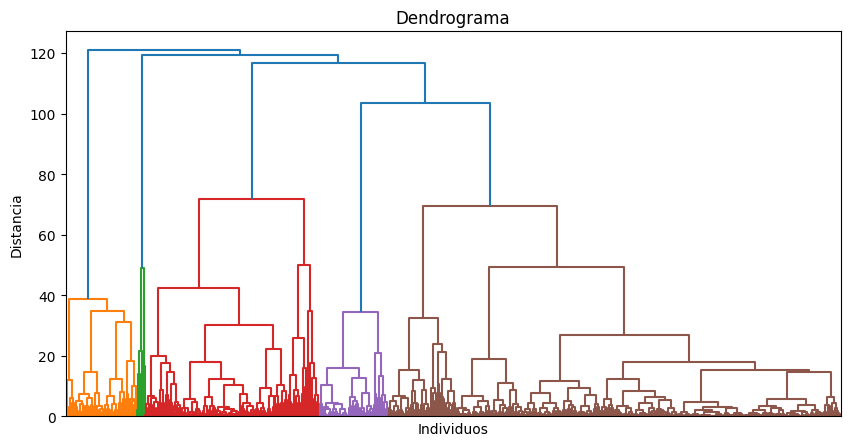

In [ ]:
# visualización clustering jerarquico
dist_matrix = linkage(scaled_features, method='ward')
# Visualizar el dendrograma
plt.figure(figsize=(10, 5))
dendrogram(dist_matrix,no_labels=True)
plt.title('Dendrograma')
plt.xlabel('Individuos')
plt.ylabel('Distancia')
plt.show()

In [ ]:
jerarquico = AgglomerativeClustering(3)
jerarquico.fit(scaled_features )
jerarquico.labels_

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
pd.Series(jerarquico.labels_).value_counts()

,count
0,7749
1,800
2,87


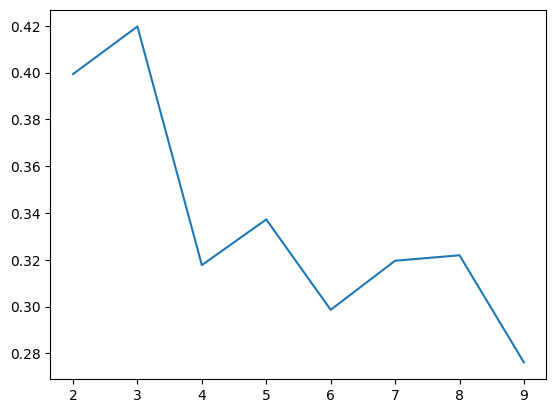

In [ ]:
silueta =[]
n_cluster=range(2,10)
for i in n_cluster:
  jerarquico = AgglomerativeClustering(i)
  jerarquico.fit(scaled_features)
  score = silhouette_score(scaled_features,jerarquico.labels_ )
  silueta.append(score)
plt.plot( list(n_cluster), silueta  )

In [ ]:
silhouette_avg_jerarquico = silhouette_score(scaled_features, jerarquico.labels_)
print(f"Silhouette Score para el clustering jerárquico: {silhouette_avg_jerarquico}")

Silhouette Score para el clustering jerárquico: 0.2760954723989816


# **ANALISIS CLUSTERING JERARQUICO**


En el modelo de clustering jerárquico se evaluaron diferentes números de clusters utilizando el Silhouette Score como métrica de calidad, encontrando que el valor más alto se presenta con 3 clusters, con un puntaje aproximado de 0.276. Este resultado indica que, aunque el modelo logra agrupar a los clientes en diferentes segmentos, la separación entre los grupos no es muy fuerte, lo que sugiere que algunos clusters pueden compartir características similares. Además, a medida que aumenta el número de clusters el Silhouette Score disminuye, lo que indica que dividir más los datos no mejora la calidad de la segmentación. Por lo tanto, el modelo jerárquico ofrece una segmentación válida, pero con una estructura de grupos menos definida en comparación con los otros métodos.



# **ANALISIS FINAL**

Al comparar los tres modelos de clustering, se observa que DBSCAN presenta el mejor desempeño, ya que obtiene el Silhouette Score más alto (≈0.867), lo que indica una separación mucho más clara entre los grupos y una mayor cohesión interna dentro de cada cluster. Por otro lado, K-Means muestra un desempeño intermedio con un Silhouette Score cercano a 0.315, logrando una segmentación razonable pero con menor diferenciación entre los grupos. Finalmente, el clustering jerárquico presenta el resultado más bajo con un Silhouette Score de aproximadamente 0.276, lo que sugiere que los clusters formados no están tan bien separados. En conclusión, para este conjunto de datos el modelo DBSCAN resulta ser el más eficiente, ya que logra identificar estructuras naturales de densidad y detectar clientes atípicos, proporcionando una segmentación más clara y robusta del comportamiento financiero de los clientes.

